# Swin TRADES Model Attack Evaluation (Single Epsilon)
Loads a **TRADES-trained** model and **clean test data** from Google Drive, then evaluates clean, FGSM, and PGD in separate cells with progress bars.

In [ ]:

import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix, roc_auc_score
from tqdm.auto import tqdm

try:
    import timm
except ImportError:
    !pip -q install timm
    import timm

from torchvision import transforms


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:


from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive')
DATA_ROOT  = DRIVE_ROOT / 'outputs_swin_lccfasd_robust2' / 'clean_dataset'
MODEL_PATH = DRIVE_ROOT / 'outputs_swin_lccfasd_robust_improved' / 'strategy_TRADES_PGD' / 'best_model.pth'
OUT_ROOT   = DRIVE_ROOT / 'outputs_swin_lccfasd_attack_eval_trades_single_eps'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

TEST_DIR = DATA_ROOT / 'test'

MODEL_NAME  = 'swin_base_patch4_window7_224'
NUM_CLASSES = 2
IMG_SIZE    = 224
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
CFG = {
    'batch_size': 16,
    'num_workers': 2,
    'epsilon': 4/255,
    'pgd_alpha': 1/255,
    'pgd_steps': 7,
}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('TEST_DIR  :', TEST_DIR, '| exists =', TEST_DIR.exists())
print('MODEL_PATH:', MODEL_PATH, '| exists =', MODEL_PATH.exists())
print('OUT_ROOT  :', OUT_ROOT)
print('DEVICE    :', DEVICE)
print('epsilon   :', CFG['epsilon'])


TEST_DIR  : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset/test | exists = True
MODEL_PATH: /content/drive/MyDrive/outputs_swin_lccfasd_robust_improved/strategy_TRADES_PGD/best_model.pth | exists = True
OUT_ROOT  : /content/drive/MyDrive/outputs_swin_lccfasd_attack_eval_trades_single_eps
DEVICE    : cuda
epsilon   : 0.01568627450980392


In [ ]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)


In [ ]:

REAL_NAMES  = {'real'}
SPOOF_NAMES = {'spoof', 'fake', 'attack'}
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class LCCFASDDataset(Dataset):
    # 0 = real, 1 = spoof
    def __init__(self, split_dir, transform=None):
        self.transform = transform
        self.samples, self.labels = [], []
        split_dir = Path(split_dir)
        for cls_dir in sorted(split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            name = cls_dir.name.lower()
            if name in REAL_NAMES:
                label = 0
            elif name in SPOOF_NAMES:
                label = 1
            else:
                continue
            for f in cls_dir.rglob('*'):
                if f.is_file() and f.suffix.lower() in IMG_EXTS:
                    self.samples.append((f, label))
                    self.labels.append(label)
        if not self.samples:
            raise RuntimeError(f'No images found in {split_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_ds = LCCFASDDataset(TEST_DIR, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False,
                         num_workers=CFG['num_workers'], pin_memory=True)

cnt = Counter(test_ds.labels)
print('Test summary:')
print(f"  total={len(test_ds):,} | real={cnt.get(0,0):,} | spoof={cnt.get(1,0):,} | batches={len(test_loader)}")


Test summary:
  total=7,580 | real=314 | spoof=7,266 | batches=474


In [ ]:

def build_model():
    return timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(DEVICE)

def load_trades_model(model_path):
    assert Path(model_path).exists(), f'Model not found: {model_path}'
    model = build_model()
    state = torch.load(model_path, map_location=DEVICE)
    if isinstance(state, dict) and 'model' in state:
        state = state['model']
    missing, unexpected = model.load_state_dict(state, strict=False)
    print('Loaded model.')
    print('Missing keys   :', len(missing))
    print('Unexpected keys:', len(unexpected))
    return model

model = load_trades_model(MODEL_PATH)
model.eval()


Loaded model.
Missing keys   : 0
Unexpected keys: 0


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [ ]:

def clamp_normalized(x):
    mean = torch.tensor(MEAN, device=x.device).view(1,3,1,1)
    std  = torch.tensor(STD, device=x.device).view(1,3,1,1)
    x_min = (0.0 - mean) / std
    x_max = (1.0 - mean) / std
    return torch.max(torch.min(x, x_max), x_min)

def fgsm_attack(model, x, y, epsilon):
    x_adv = x.detach().clone().requires_grad_(True)
    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    x_adv = x_adv + epsilon * grad.sign()
    return clamp_normalized(x_adv).detach()

def pgd_attack(model, x, y, epsilon, alpha, steps, random_start=True):
    x_orig = x.detach()
    if random_start:
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
        x_adv = clamp_normalized(x_adv)
    else:
        x_adv = x_orig.clone()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
            x_adv = clamp_normalized(x_orig + delta)
    return x_adv.detach()


In [ ]:

def compute_far_frr_hter(cm):
    tn, fp, fn, tp = cm.ravel()
    far = 100.0 * (fn / max(fn + tp, 1))   # spoof accepted as real
    frr = 100.0 * (fp / max(tn + fp, 1))   # real rejected as spoof
    hter = (far + frr) / 2.0
    return far, frr, hter

def evaluate_model(model, loader, attack=None, attack_kwargs=None, desc='Eval'):
    model.eval()
    attack_kwargs = attack_kwargs or {}
    y_true, y_pred, y_score = [], [], []
    running_loss = 0.0

    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        if attack is not None:
            x = attack(model, x, y, **attack_kwargs)
        with torch.no_grad():
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)
        running_loss += loss.item() * x.size(0)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_score.extend(probs.cpu().numpy().tolist())

    y_true = np.array(y_true); y_pred = np.array(y_pred); y_score = np.array(y_score)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    far, frr, hter = compute_far_frr_hter(cm)
    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = float('nan')

    return {
        'loss': running_loss / len(loader.dataset),
        'acc': 100.0 * accuracy_score(y_true, y_pred),
        'prec_macro': 100.0 * precision_score(y_true, y_pred, average='macro', zero_division=0),
        'rec_macro': 100.0 * recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': 100.0 * f1_score(y_true, y_pred, average='macro', zero_division=0),
        'bacc': 100.0 * balanced_accuracy_score(y_true, y_pred),
        'far': far,
        'frr': frr,
        'hter': hter,
        'auc': 100.0 * auc if not np.isnan(auc) else np.nan,
        'cm': cm.tolist(),
    }

def pretty_print_results(title, m):
    print('\n' + '='*42)
    print(title)
    print('='*42)
    print(f"Loss            : {m['loss']:.4f}")
    print(f"Accuracy        : {m['acc']:.2f}%")
    print(f"Balanced Acc    : {m['bacc']:.2f}%")
    print(f"Precision Macro : {m['prec_macro']:.2f}%")
    print(f"Recall Macro    : {m['rec_macro']:.2f}%")
    print(f"F1 Macro        : {m['f1_macro']:.2f}%")
    print(f"HTER            : {m['hter']:.2f}%")
    print(f"FAR             : {m['far']:.2f}%")
    print(f"FRR             : {m['frr']:.2f}%")
    print(f"AUC             : {m['auc']/100:.4f}" if not np.isnan(m['auc']) else "AUC             : nan")

def save_json(obj, path):
    path = Path(path)
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)

def plot_cm(cm, title, save_path):
    cm = np.array(cm)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['real','spoof'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['real','spoof'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center')
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_summary(df, save_path):
    metrics_to_plot = ['acc', 'f1_macro', 'bacc', 'hter']
    fig, ax = plt.subplots(figsize=(8,4.5))
    x = np.arange(len(metrics_to_plot)); w = 0.25
    for i, setting in enumerate(df['setting'].tolist()):
        vals = [df.loc[df['setting']==setting, m].values[0] for m in metrics_to_plot]
        ax.bar(x + (i-1)*w, vals, width=w, label=setting)
    ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
    ax.set_ylabel('Score'); ax.set_title('TRADES — Clean vs FGSM vs PGD')
    ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()
    plt.close()


Clean eval:   0%|          | 0/474 [00:00<?, ?it/s]


TRADES — CLEAN
Loss            : 0.2682
Accuracy        : 90.47%
Balanced Acc    : 87.11%
Precision Macro : 63.66%
Recall Macro    : 87.11%
F1 Macro        : 68.43%
HTER            : 12.89%
FAR             : 9.22%
FRR             : 16.56%
AUC             : 0.9524


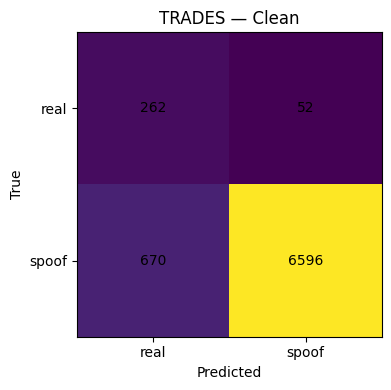

In [ ]:

clean_metrics = evaluate_model(model, test_loader, desc='Clean eval')
pretty_print_results('TRADES — CLEAN', clean_metrics)
save_json(clean_metrics, OUT_ROOT / 'clean_metrics.json')
plot_cm(clean_metrics['cm'], 'TRADES — Clean', OUT_ROOT / 'cm_clean.png')


FGSM eval eps=0.015686:   0%|          | 0/474 [00:00<?, ?it/s]


TRADES — FGSM (eps=0.01568627450980392)
Loss            : 0.5416
Accuracy        : 82.69%
Balanced Acc    : 80.15%
Precision Macro : 57.60%
Recall Macro    : 80.15%
F1 Macro        : 58.61%
HTER            : 19.85%
FAR             : 17.08%
FRR             : 22.61%
AUC             : 0.8584


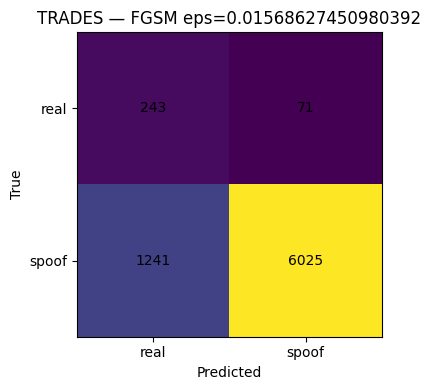

In [ ]:

fgsm_metrics = evaluate_model(
    model, test_loader,
    attack=fgsm_attack,
    attack_kwargs={'epsilon': CFG['epsilon']},
    desc=f'FGSM eval eps={CFG["epsilon"]:.6f}'
)
pretty_print_results(f'TRADES — FGSM (eps={CFG["epsilon"]})', fgsm_metrics)
save_json(fgsm_metrics, OUT_ROOT / 'fgsm_metrics.json')
plot_cm(fgsm_metrics['cm'], f'TRADES — FGSM eps={CFG["epsilon"]}', OUT_ROOT / 'cm_fgsm.png')


PGD eval eps=0.015686:   0%|          | 0/474 [00:00<?, ?it/s]


TRADES — PGD (eps=0.01568627450980392)
Loss            : 0.5813
Accuracy        : 81.57%
Balanced Acc    : 78.81%
Precision Macro : 57.00%
Recall Macro    : 78.81%
F1 Macro        : 57.45%
HTER            : 21.19%
FAR             : 18.18%
FRR             : 24.20%
AUC             : 0.8371


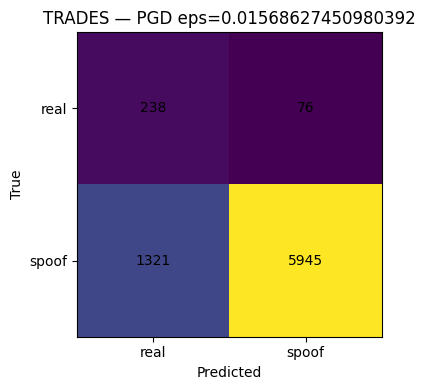

In [ ]:

pgd_metrics = evaluate_model(
    model, test_loader,
    attack=pgd_attack,
    attack_kwargs={
        'epsilon': CFG['epsilon'],
        'alpha': CFG['pgd_alpha'],
        'steps': CFG['pgd_steps'],
        'random_start': True,
    },
    desc=f'PGD eval eps={CFG["epsilon"]:.6f}'
)
pretty_print_results(f'TRADES — PGD (eps={CFG["epsilon"]})', pgd_metrics)
save_json(pgd_metrics, OUT_ROOT / 'pgd_metrics.json')
plot_cm(pgd_metrics['cm'], f'TRADES — PGD eps={CFG["epsilon"]}', OUT_ROOT / 'cm_pgd.png')


,setting,loss,acc,prec_macro,rec_macro,f1_macro,bacc,far,frr,hter,auc
0,clean,0.268219,90.474934,63.664699,87.109230,68.432778,87.109230,9.221029,16.560510,12.890770,95.242391
1,fgsm,0.394914,86.464380,59.906469,83.646107,62.750052,83.646107,13.281035,19.426752,16.353893,91.039279
2,pgd,0.410628,86.029024,59.566759,83.114313,62.185768,83.114313,13.707680,20.063694,16.885687,90.112640


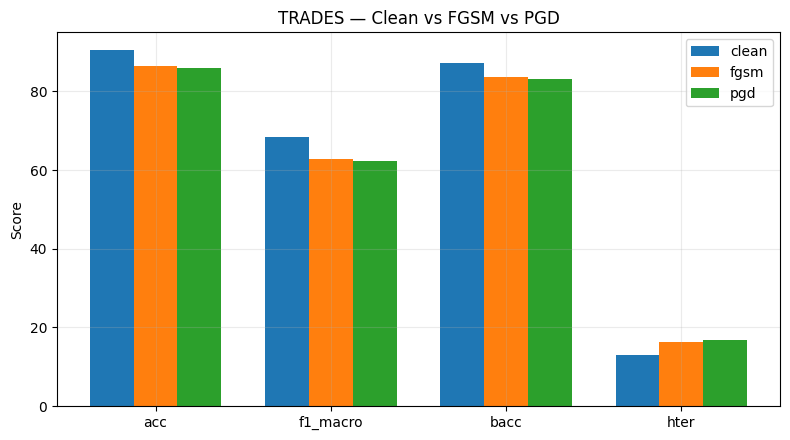

Saved to: /content/drive/MyDrive/outputs_swin_lccfasd_attack_eval_trades_single_eps


In [ ]:

summary_df = pd.DataFrame([
    {'setting':'clean', **{k:v for k,v in clean_metrics.items() if k != 'cm'}},
    {'setting':'fgsm',  **{k:v for k,v in fgsm_metrics.items() if k != 'cm'}},
    {'setting':'pgd',   **{k:v for k,v in pgd_metrics.items() if k != 'cm'}},
])
display(summary_df)
summary_df.to_csv(OUT_ROOT / 'summary_metrics.csv', index=False)
plot_summary(summary_df, OUT_ROOT / 'summary_plot.png')
print('Saved to:', OUT_ROOT)
